# Klasterovanje

**Klasterovanje** se može definisati kao problem identifikacije grupa (klastera) u podacima takvih da instance u okviru pojedinačnih klastera budu što sličnije, dok se instance iz različitih klastera što više razlikuju. Sličnost/različitost su predstavljeni nekom merom sličnosti/različitosti (npr. euklidsko rastojanje, varijansa...). Odluka koja mera sličnosti će biti korišćena zavisi od upotrebe.

Klasterovanje spada u metode _nenadgledanog učenja_, s obzirom na to da nemamo informacije o tome šta je potrebno naučiti tj. instance nemaju pridruženu oznake klastera kojima pripadaju na osnovu kojih bismo mogli da evaluiramo performanse modela.

Pojam klasterovanja nije jednoznačno definisan. U jednom skupu se može identifikovati više različitih grupisanja.

<img src="assets/cluster_ambiguousness.png" width='70%'>

Pojam klasterovanja nije jednoznačno definisan ne samo u odnosu na broj klastera koji se u podacima mogu naći, već i u odnosu na to kako definišemo klastere. Neke od vrsta klastera su:  

* globularni 
* gustinski (eng. *density*)
* hijerarhijski
* dobro razdvojeni (eng. *well separated clusters*, *hard clustering*)
* preklapajući (eng. *overlapping clusters*, *fuzzy/soft clustering*)
* ...

*Globularni* ili *centrični klasteri* su grupe tačaka koje popunjavaju unutrašnjost lopte ili eventualno elipsoida. *Gustinski klasteri* su klasteri čije su tačke razdvojene od tačaka drugih klastera regionima manje gustine. *Hijerarhijski klasteri* su ili pojedinačne tačke ili klasteri čije su tačke takođe organizovane u strukturu hijerarhijskih klastera. *Dobro razdvojeni klasteri* su grupe tačaka koje su bliže drugim tačkama svoje grupe nego bilo kojoj tački iz neke druge grupe. *Preklapajući klasteri* dozvoljavaju da tačke pripadaju istovremeno većem broju klastera .

*Napomena*: Ovde smo naveli samo vrste koje će biti pokrivene na važbama.

## 1. K-means

Metoda klasterovanja zasnovana na reprezentativnim predstavnicima klastera. Vrši podelu podataka na disjunktne klastere (tzv. *hard clustering*). Najpopularnije tehnike su:

* K-means
* K-medoid 

**K-means** definiše predstavnika klastera kao ***centroidu*** (najčešće usrednjena vrednost elemenata klastera), dok **K-medoid** definiše predstavnika klastera kao ***medoidu*** (element čija je suma udaljenosti od svih ostalih elemenata unutar klastera minimalna, dakle to mora da bude neka od instanci iz skupa podataka!)

U nastavku ćemo se baviti K-means algoritmom, dok istraživanje o K-medoid algoritmu ostaje za domači [literatura](https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.KMedoids.html). 

Algoritam **k-sredina** (engl. ***k-means***) je jedan od najstarijih i najšire korišćenih algoritama za klasterovanje. Pronalazi globularne oblike klastera.

K-means predstavlja **iterativni** algoritam koji deli podatke u _K_ klastera (**broj klastera unapred definisan**). Svaka tačka pripada **tačno jednom klasteru**.

Dodeljuje instance klasterima na način da suma kvadrata rastojanja između tačaka iz klastera i centroide bude što manja. Drugim rečima, u okviru ovog algoritma se vrši minimizacija sledeće funkcije greške (eng. *Sum of the Squared Error*, *SSE*):
$$SSE = \sum_{i=1}^{k}\sum_{x\in C_i} d(x, c_i)^2$$
po $c_i$ (centroida klastera $C_i$), gde je **_d_** euklidsko rastojanje (u opštem slučaju moguće je koristiti i neko drugo rastojanje).

*Napomena*: Ova pretpostavka čini algoritam primenljivim samo na podatke koji se mogu uprosečavati, poput vektora. 

<img src="assets/k-means.png">


Polaznih *k* centroida se bira nasumično, a potom se ponavljaju sledeći koraci:

1. instance se raspoređuju u nove klastere tako što se svaka instanca pridruži najbližoj centroidi

2. izračunavaju se nove centroide kao prosek instanci koje su im pridružene


Ovi koraci se izvršavaju sve dok se centroide menjaju. Kada su centroide iste u dve uzastopne iteracije, algoritam se zaustavlja.

Ukoliko znamo nešto o strukturi podataka sa kojima radimo, početni centroidi se mogu i pažljivije odabrati.

**Pozitivne strane**

 * 👍 Jednostavan, fleksibilan, efikasan. 
 * 👍 Jednostavan za interpretaciju.

**Potencijalni problemi**
 * 🤔 $\rightarrow$ 👍 _Da li postoji više jednako dobrih klastera (da li postoji više globalnih minimuma?)_ - Da, može biti više jednako dobrih podela (više globalnih minimuma).
 * 🤔 $\rightarrow$ 💡 $\rightarrow$ 👍   _Da li se prilikom minimizacije možemo zaglaviti u lokalnom minimumu?_ - Da, što može biti problem, ali ga rešavamo pokretanjem algoritma više puta.
 * 🤔 Pronalazi globularne klastere - ako minimizujemo eulidsko rastojanje. (može da bude problem, zavisi od problema koji rešavamo).
 * 👎 Osetljiv na autjalere - zbog kvadriranja euklidskog rastojanja.

### Primer 1 - Klasterovanje pasa

U uvodnom primeru ćemo koristiti skup podataka <code>dogs.csv</code>.

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('datasets/dogs.csv')
data

,breed,height,weight
0,Border Collie,20,45
1,Boston Terrier,16,20
2,Brittany Spaniel,18,35
3,Bullmastiff,27,120
4,Chihuahua,8,8
5,German Shepherd,25,78
6,Golden Retriever,23,70
7,Great Dane,32,160
8,Portuguese Water Dog,21,50
9,Standard Poodle,19,65


Atribut <code>bread</code> možemo smatrati nekom vrstom identifikatora instanci, s obzirom da ima jedinstvene vrednosti za svaku instancu, i stoga ga izbacujemo iz daljeg razmatranja. Umesto izbacivanja kolone možemo je npr. koristiti kao indekse instanci.

Pošto postoje dva numerička atributa, možemo ih i vizuelizovati. 

<Axes: xlabel='height', ylabel='weight'>

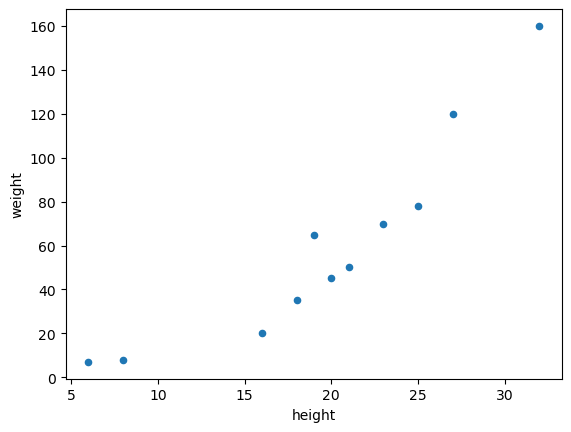

In [3]:
data.plot.scatter(x='height', y='weight')

Klasterovanje ćemo izvršiti na osnovu atributa _height_ i _weight_.

In [4]:
feature_names = ['height', 'weight']
feature_names

['height', 'weight']

In [5]:
X = data[feature_names]
X

,height,weight
0,20,45
1,16,20
2,18,35
3,27,120
4,8,8
5,25,78
6,23,70
7,32,160
8,21,50
9,19,65


❔ Da li je potrebno izvršiti normalizaciju prilikom korišćenja K-means? (Da, zašto?)


In [6]:
from sklearn.preprocessing import MinMaxScaler

In [7]:
scaler = MinMaxScaler()

In [8]:
X = pd.DataFrame(scaler.fit_transform(X), columns=feature_names)
X

,height,weight
0,0.538462,0.248366
1,0.384615,0.084967
2,0.461538,0.183007
3,0.807692,0.738562
4,0.076923,0.006536
5,0.730769,0.464052
6,0.653846,0.411765
7,1.000000,1.000000
8,0.576923,0.281046
9,0.500000,0.379085


Nakon normalizacije vršimo klasterovanje u 2 klastera, koristeći algoritam K-means. 

`Scikit-learn` biblioteka omogućava korišćenje algortima k-sredina kroz `KMeans` klasu `cluster` paketa. `KMeans` konstruktorska funkcija očekuje broj klastera i inicijalizaciju kojom se utiče na izbor početnih centroida. Postoje i druga podešavanja algoritma kroz maksimalan broj iteracija, izbor pozadinskog algoritma, paralelizaciju i slično. Mera bliskosti je Euklidsko rastojanje.

In [9]:
from sklearn.cluster import KMeans

In [10]:
kmeans = KMeans(n_clusters=2)

❔ Zašto ne vršimo podelu podataka na trening i test?

In [11]:
kmeans.fit(X)

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


Sada ćemo da vizuelizujemo rezultate koje smo dobili. Neke bitne informacije su nam:
   
   * Koja instanca pripada kom klasteru?
   * Vrednosti centroida za svaki od klastera?
   * Kolika je vrednost mera suma kvadrata grešaka (*SSE*)?

Obeležja klastera pridružena instancama se mogu dobiti kroz `labels_` svojstvo naučenog modela ili pozivom funkcije `predict`.

In [12]:
kmeans.labels_

array([1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0], dtype=int32)

In [13]:
kmeans.predict(X)

array([1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0], dtype=int32)

Koje instance pripadaju kom klasteru možemo izdvojiti na sledeći način: 

In [14]:
X[kmeans.labels_ == 0]          

,height,weight
1,0.384615,0.084967
4,0.076923,0.006536
10,0.000000,0.000000


In [15]:
X[kmeans.labels_ == 1]          

,height,weight
0,0.538462,0.248366
2,0.461538,0.183007
3,0.807692,0.738562
5,0.730769,0.464052
6,0.653846,0.411765
7,1.000000,1.000000
8,0.576923,0.281046
9,0.500000,0.379085


Informacije o centroidima klastera se mogu dobiti pomoću svojstva `cluster_centers_`.

In [16]:
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=feature_names)
centroids

,height,weight
0,0.153846,0.030501
1,0.658654,0.463235


Centroide u polaznom prostoru atributa (pre skaliranja).

In [17]:
centroids_rescaled = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=feature_names)
centroids_rescaled

,height,weight
0,10.000,11.666667
1,23.125,77.875000


Suma kvadrata grešaka (*SSE*) se može dobiti pomoću svojstva <code>inertia_</code>.

In [18]:
kmeans.inertia_

0.8479588365514269

Ponovo iscrtavamo skup podataka tako da instance iz različitih klastera budu obojene različitom bojom. Na grafiku dodatno iscrtavamo posebno istaknute centroide klastera.

In [19]:
import matplotlib.pyplot as plt

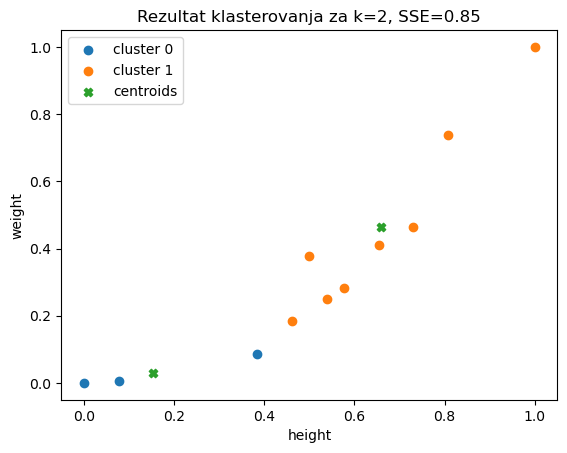

In [20]:
for cluster_label in set(kmeans.labels_):
    elems = X[kmeans.labels_ == cluster_label]
    plt.scatter(elems['height'], elems['weight'], label='cluster ' + str(cluster_label))

plt.scatter(centroids['height'], centroids['weight'], marker='X', label='centroids') 
    
plt.xlabel('height')
plt.ylabel('weight')
plt.title('Rezultat klasterovanja za k=2, SSE={}'.format(round(kmeans.inertia_, 2)))
plt.legend()
plt.show()   

Detaljnijim pregledom klastera, vidimo da su u jednom klasteru velike rase, a u drugom srednje i male rase.

In [21]:
data[kmeans.labels_ == 1]

,breed,height,weight
0,Border Collie,20,45
2,Brittany Spaniel,18,35
3,Bullmastiff,27,120
5,German Shepherd,25,78
6,Golden Retriever,23,70
7,Great Dane,32,160
8,Portuguese Water Dog,21,50
9,Standard Poodle,19,65


In [22]:
data[kmeans.labels_ == 0]

,breed,height,weight
1,Boston Terrier,16,20
4,Chihuahua,8,8
10,Yorkshire Terrier,6,7


Ocenu klasterovanja možemo dobiti korišćenjem bibliotečke funkcije `score` koja vraća negativna vrednost *SSE* funkcije. 

In [23]:
kmeans.score(X)

-0.8479588365514269

### Koeficijent senke (eng. *silhouette coefficient*)

**Koeficijent senke** je mera kvaliteta klasterovanja (tj. dobijenih klastera) koja ocenjuje koliko (u kojoj meri) su instance grupisane sa instancama koje su slične njima samima. Vrednost koeficijenta senke izražava se kao mera sličnosti objekta sa svojim klasterom (kohezija) u poređenju sa drugim klasterima (separacija).

**Kohezija** (eng. *cohesion*) je mera unutarklasne sličnosti. Meri koliko su instance unutar istog klastera slični, odnosno koliko su tačke blizu jedna drugoj. To može biti na primer *SSE*. Idealno je da kohezija bude što veća, što znači da je rastojanje između tačaka unutar istog klastera minimalno.

**Separacija** (eng. *separation*) je mera međuklasne udaljenosti. Meri koliko su različite instance iz različitih klastera, odnosno koliko su tačke udaljene jedna od druge (razdvojenost jednog klastera od drugih). To može biti na primer *BCSS* (*Between-Cluster Sum of Squares*). Cilj je da separacija bude što veća, kako bi se jasno razlikovali različiti klasteri. 

Pomoću koeficijenta siluete merimo ove dve odlike zajedno i na taj način procenjujemo koliko su naši klasteri dobri. On se izračunava za svaku pojedinačnu instancu u skupu podataka i predstavlja meru koliko je ta instanca „dobro” smeštena u svoj klaster u odnosu na ostale klastere. Visok koeficijent siluete znači da je instanca dobro smeštena u svoj klaster, dok niski koeficijent siluete ukazuje da instanca nije dobro smeštena u svoj klaster i da bi mogla bolje da se uklopi u neki drugi klaster. 

<img src="assets/cohesion_and_separation.png" width="70%">

Koeficijent senke se računa za svaku instancu pojedinačno na sledeći način:

1. Za $i$-tu instancu računamo usrednjeno rastojanje od svih instanci iz istog klastera (Umesto rastojanja može da se koriste i druge mere različitosti). Obeležimo izračunatu vrednost sa $a_i$.

2. Za $i$-tu instancu i sve klastere koji ne sadrže $i$-tu instancu računamo usrednjeno rastojanje instance od svih elemenata iz svakog klastera. Pronalazimo minimalno rastojanje i obeležimo ga sa $b_i$.

3. Silueta koeficijent za $i$-tu instancu računamo : $s_i = \frac{b_i - a_i}{max(a_i, b_i)}$

Vrednosti $s_i$ se nalaze u rasponu od -1 do 1. Vrednost 0 označava da je instanca smeštena na granici između dva klastera. Negativne vrednosti nisu poželjne, pošto odgovaraju slučaju kada je $a_i > b_i$, tj. kada je usrednjeno rastojanje između instanci u klasteru veće nego minimalno usrednjeno rastojanje od instanci iz drugih klastera.

Težimo da koeficijent senke bude pozitivan ($a_i < b_i$) i da $a_i$ bude što bliži 0.

Koeficijent senke klastera računamo kao prosečnu vrednost $s_i$ svih instanci iz klastera.

Kao ukupna mera kvaliteta klasterovanja se dobija usrednjavanjem $s_i$ svih instanci skupa podataka.

In [24]:
from sklearn.metrics import silhouette_samples, silhouette_score

In [25]:
silhouette_values = silhouette_samples(X, kmeans.labels_)
silhouette_values

array([ 0.28981652,  0.242704  , -0.12137722,  0.53267774,  0.73560541,
        0.57851663,  0.56163616,  0.43579723,  0.40507931,  0.39309297,
        0.71035336])

Ponovo vizuelizujemo skup podatka tako da boja svake instance odražava vrednost njenog koeficijenta senke.

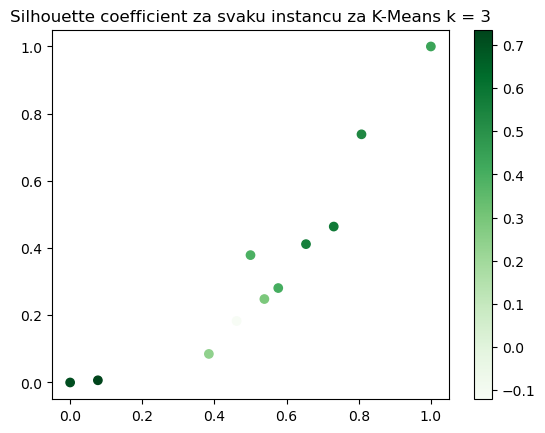

In [26]:
plt.scatter(X['height'], X['weight'], c=silhouette_values, cmap="Greens")
plt.colorbar()
plt.title("Silhouette coefficient za svaku instancu za K-Means k = 3")
plt.show()

In [27]:
silhouette_values.mean()

0.4330820099418202

In [28]:
silhouette_score(X, kmeans.labels_)              

0.4330820099418202

### Izbor optimalnog broja klastera

Jedan od glavnih izazova pri korišćenju *K-Means* modela je izbor broja klastera. U praksi obično radimo sa većim skupovima podataka u kojima nije baš uvek intuitivno pretpostaviti broj postojećih klastera. Optimalan broj klastera određujemo tako što pratimo ponašanje modela za različite vrednosti ovog parametra, a potom odaberemo najoptimalniju.

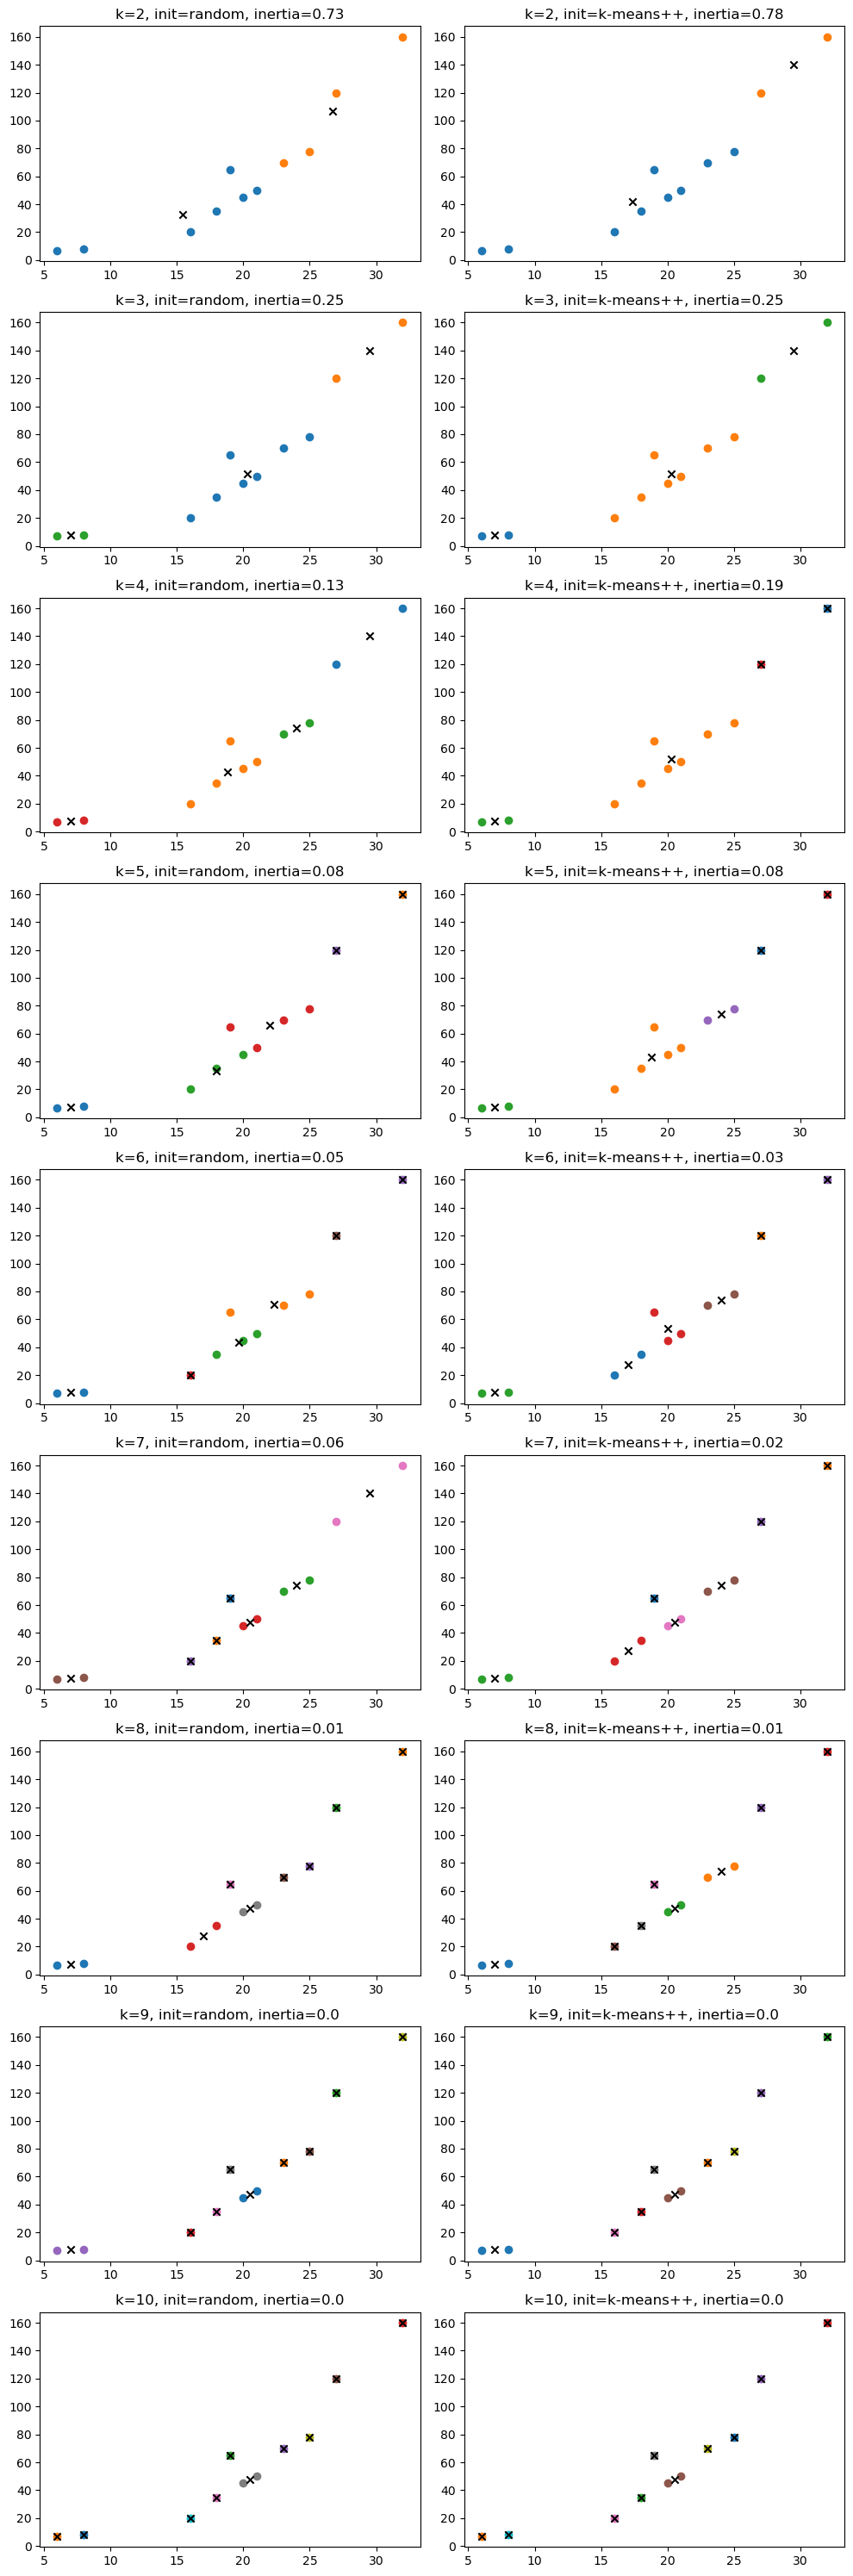

In [29]:
ks = range(2, X.shape[0]) 
inits = ['random', 'k-means++']      #algoritam za inicijalni odabir centroida

fig = plt.figure(figsize=(10,30))
idx = 1

for k in ks:
    for init in inits:
        kmeans = KMeans(n_clusters=k, init=init, n_init='auto')
        kmeans.fit(X)
        
        fig.add_subplot(len(ks), len(inits), idx)
        idx += 1
        for label in range(k):
            cluster = data[kmeans.labels_ == label]
            plt.scatter(cluster['height'], cluster['weight'])
        
        centroids = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=feature_names)
        plt.scatter(centroids['height'], centroids['weight'], color='black', marker='x')
            
        plt.title(f'k={k}, init={init}, inertia={round(kmeans.inertia_, 2)}')
        
plt.tight_layout()

Sa porastom broja klastera, *SSE* se smanjuje, jer će instance biti bliže centroidama. Vrednost *SSE* je najmanja kada je broj klastera jednak broju instanci (svaki klaster sadrži po 1 instancu). S obzirom na ovu informaciju, potrebno je da odredimo minimalan broj klastera za koji se dobija razumna vrednost *SSE*.

### Pravilo lakta  vs metod siluete 

Jedan od najpoznatijih heurističkih metoda za odabir optimalnog broja klastera je **pravilo lakta** (eng. *Elbow method*). Za različite vrednosti broja klastera izvrši se klasterovanje i iscrta grafik promene *SSE*. Optimalan broj klastera odgovara tački nagle promene brzine opadanja funkcije *SSE*, tj. u tački nakon koje suma kvadrata grešaka prestaje drastično da opada (odgovara „laktu“ grafika funkcije *SSE*). Pretpostavka ovog metoda je da su nakon „lakta“ klasteri već homogeni i dodavanje novih centroida ne doprinosi značajno smanjenju sume kvadrata rastojanja.

<img src="assets/elbow_method.png" width="50%">

Problem koji se javlja prilikom korišćenja ove heuristike je što se klasteri koji su jako blizu spajaju u jedan (jer njihovim razdvajanjem *SSE* neće mnogo opasti).

Za rešenje ovog problema se koristi **metod siluete** (eng. *Silhouette method*). Posmatramo grafik promene koeficijenta siluete (na celom skupu podataka) dobijenog klasterovanjem sa različitim brojem klastera. Znamo da težimo što većim vrednostima koeficijenta siluete koje signaliziraju da je dobra koherencija unutar klastera, kao i separacija između klastera. Biramo broj klastera kome odgovara maksimalna vrednost koeficijenta siluete.

Vršimo ponovo klasterovanje sa različitim brojem klastera i čuvamo dobijene vrednosti *SSE* i koeficijenta siluete. 

In [30]:
ks = range(2, X.shape[0]) 

silhouettes = []
inertias = []

for k in ks:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)        
        
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(X, kmeans.labels_))

Isrctavamo uporedno grafike promene funkcije *SSE* i koeficijenta siluete u odnosu na promenu broja klastera.

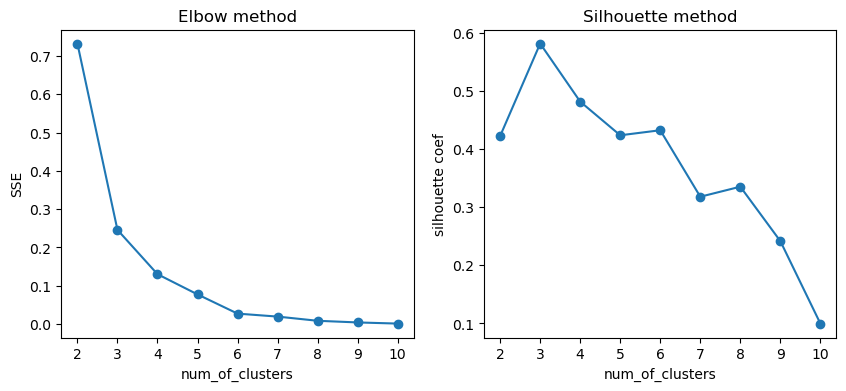

In [31]:
fig = plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(ks, inertias, marker='o')
plt.xticks(ks)
plt.ylabel('SSE')
plt.xlabel('num_of_clusters')
plt.title('Elbow method')

plt.subplot(1, 2, 2)
plt.plot(ks, silhouettes, marker="o")
plt.xticks(ks)
plt.ylabel('silhouette coef')
plt.xlabel('num_of_clusters')
plt.title('Silhouette method')

plt.show()

Ako bismo možda kod metoda lakta mogli da diskutujemo da li je bolje izabrati vrednost $k=3$ ili $k=4$, na osnovu metoda siluete je očigledno da je optimalno $k=3$.

### Silhouette Diagram

Još detaljnija vizuelizacija je silhouette dijagram koji se dobija vizuelizacijom koeficijenta siluete za svaku instancu klastera, sortirane opadajuće. Debljina svakog klastera nam daje informaciju o veličini klastera, a širina o shilouette skoru svake instance (što je šira to je bolje).

Dodatna informacija je i isprekidana linija koja predstavlja shilouette score svih klastera. 

For n_clusters = 2 The average silhouette_score is : 0.5210272444296898
For n_clusters = 3 The average silhouette_score is : 0.5813924452451538
For n_clusters = 4 The average silhouette_score is : 0.4276472724830383
For n_clusters = 5 The average silhouette_score is : 0.42356634638256535


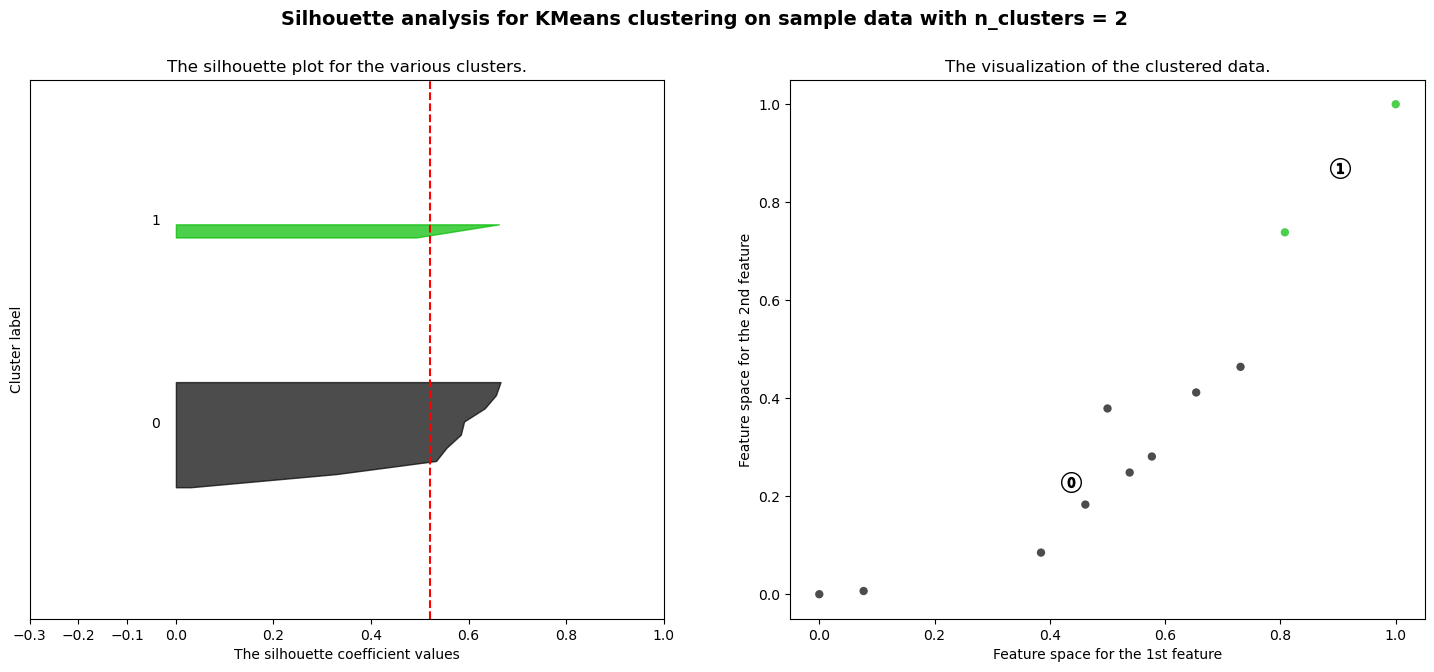

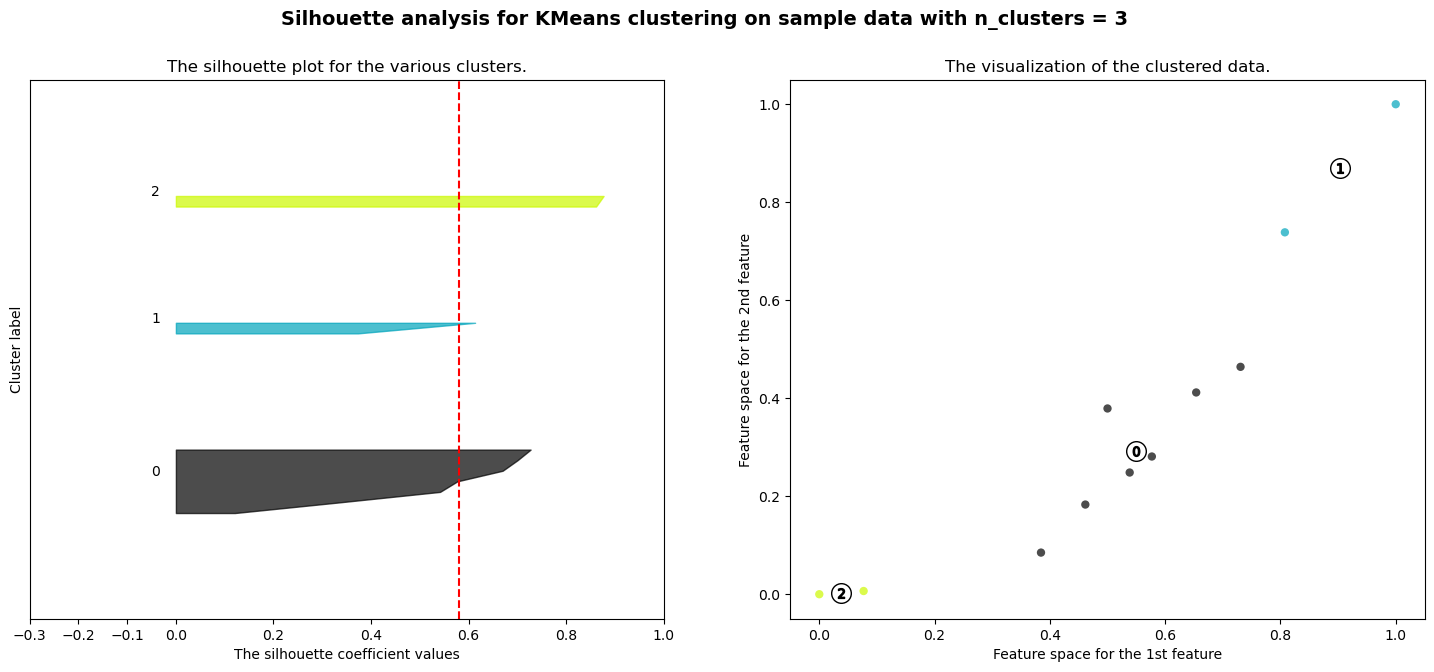

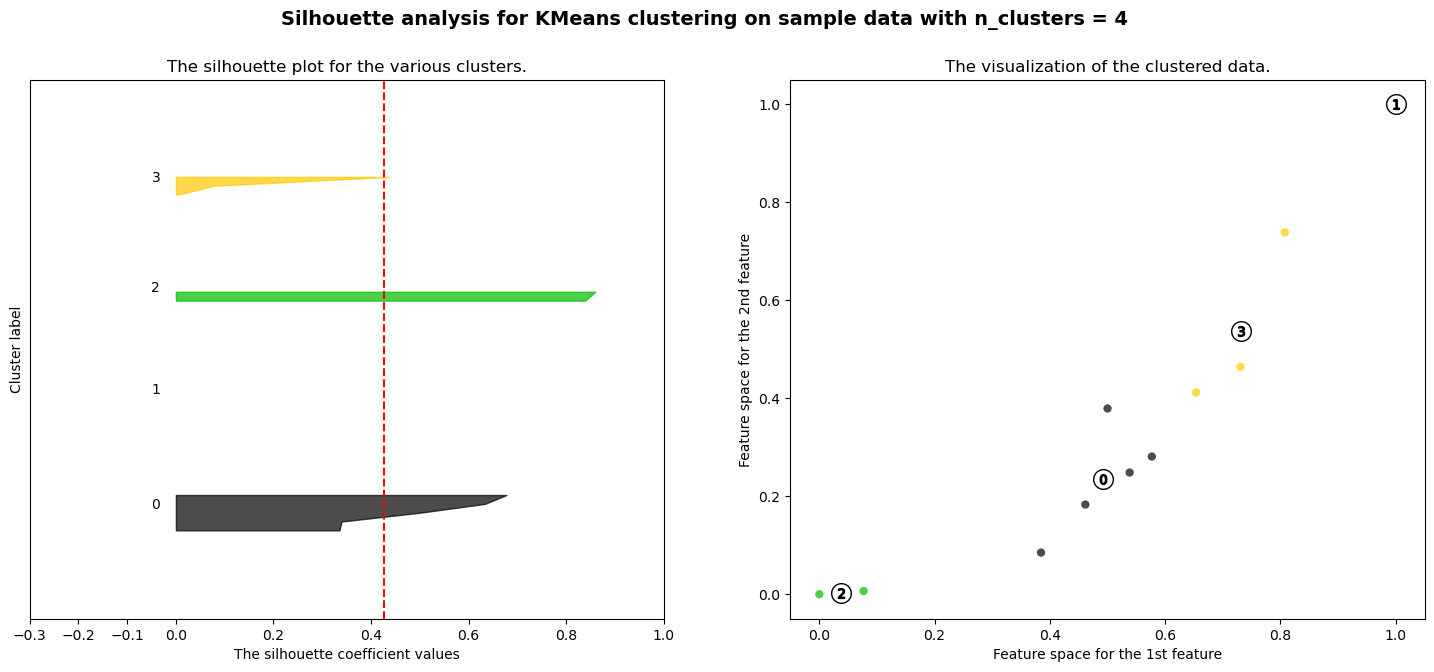

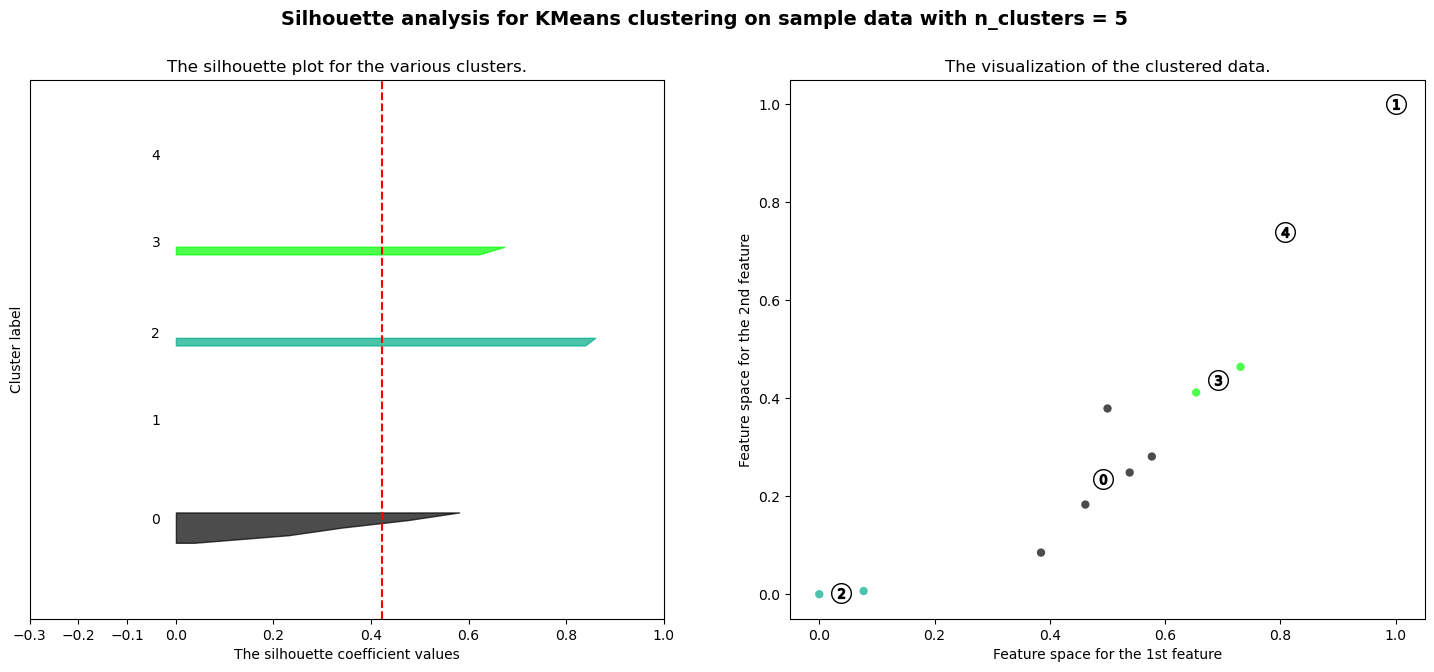

In [32]:
# pomoćna funkcija za silhouette diagram plot (preuzeto sa https://scikit-learn.org/stable/auto_examples/cluster/plot_kmeans_silhouette_analysis.html)
import numpy as np
import matplotlib.cm as cm

for n_clusters in [2, 3, 4, 5]:
    # Create a subplot with 1 row and 2 columns
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # The 1st subplot is the silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax1.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax1.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters, n_init="auto", random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax1.set_title("The silhouette plot for the various clusters.")
    ax1.set_xlabel("The silhouette coefficient values")
    ax1.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])  # Clear the yaxis labels / ticks
    ax1.set_xticks([-0.3, -0.2, -0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # 2nd Plot showing the actual clusters formed
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(
        X['height'], X['weight'], marker="o", lw=0, alpha=0.7, c=colors, edgecolor="k"
    )

    # Labeling the clusters
    centers = clusterer.cluster_centers_
    # Draw white circles at cluster centers
    ax2.scatter(
        centers[:, 0],
        centers[:, 1],
        marker="o",
        c="white",
        alpha=1,
        s=200,
        edgecolor="k",
    )

    for i, c in enumerate(centers):
        ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("The visualization of the clustered data.")
    ax2.set_xlabel("Feature space for the 1st feature")
    ax2.set_ylabel("Feature space for the 2nd feature")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Sa leve strane se nalazi silhouette diagram, a sa desne su prikazani klasteri.
Ako posmatramo za $k=2$, možemo primetiti da je jedan klaster znatno veći od drugog klastera.
Ako povećamo na $k=3$, dobijamo bolje rezultate. Ako sada posmatramo $k=4$, možemo primetiti da je silhouette score opao, kao i da se većina instanci nalazi sa leve strane isprekidane linije (silhouette score je manji od srednje vrednosti), čak i da je za neke instance manji od 0 (što znači da je došlo do pogrešnog razdvajanja klastera). Ovim smo još sigurniji da je $k=3$ najbolji izbor.

## Primer 2 - kompresija slike 


Sledeći primer ilustruje korišćenje algoritma k-sredina u kompresiji slika. Ideja je redukovati broj boja koje se koriste za prikaz same slike, a time i memoriju koju ona zahteva. 

Slika u boji predstavlja matricu piksela, pri čemu je svaki piksel definisan pomoću 3 kanala (RGB).  Svaki piksel posmatramo kao 1 instancu i vršimo klasterovanje u _k_ grupa. Nakon toga, svaki piksel zamenjujemo centroidom klastera kome pripada.

In [33]:
from sklearn.datasets import load_sample_image

Eksperiment ćemo izdvoditi nad slikom `chine.jpg` koju ćemo učitatiti iz `datasets` paketa korišćenjem funkcije `load_sample_image`. 

In [34]:
img = load_sample_image("china.jpg")

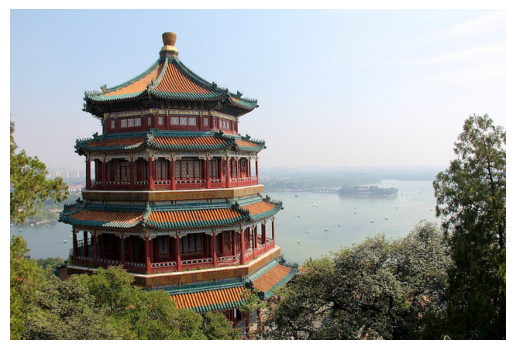

In [35]:
plt.imshow(img)
plt.axis('off')
plt.show()

In [36]:
img.shape

(427, 640, 3)

In [37]:
img_height, img_width, img_depth = img.shape

Slika je dimenzija $427 \times 640$ piksela i ima 3 kanala boja (RGB).

In [38]:
num_unique_colors = len(np.unique(img.reshape(-1, img_depth), axis=0))
num_unique_colors

96615

Dakle, originalna slika ima 96 615 različitih boja.

Pre primene algoritma k-sredina, izvrišićemo normalizaciju vrednosti piskela i transformaciju slike u 2D vektor (za k-means sliku predstavljamo kao niz piksela, pri čemu je svaki pisel predstavljen nizom od 3 vrednosti (kanala)).

In [39]:
img_scaled = img.astype(np.float64) / 255

In [40]:
X_img = img_scaled.reshape(img_height * img_width, img_depth)

In [41]:
kmeans = KMeans(n_init='auto', n_clusters=30)

In [42]:
kmeans.fit(X_img)

,n_clusters,30
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


Rekonstrukciju slike dobijamo tako što svaki piksel predstavljamo centroidom njemu odgovarajućeg klastera.

In [43]:
X_compressed = kmeans.cluster_centers_[kmeans.labels_]

Vraćamo piksele nazad na skalu [0, 255].

In [44]:
X_compressed *= 255                      
X_compressed = np.clip(X_compressed.astype('uint8'), 0, 255)

Kompresovanu sliku dobijamo reshapeing-om dobijenog niza centroida klastera (piksela).

In [45]:
img_compressed = X_compressed.reshape(img_height, img_width, img_depth)

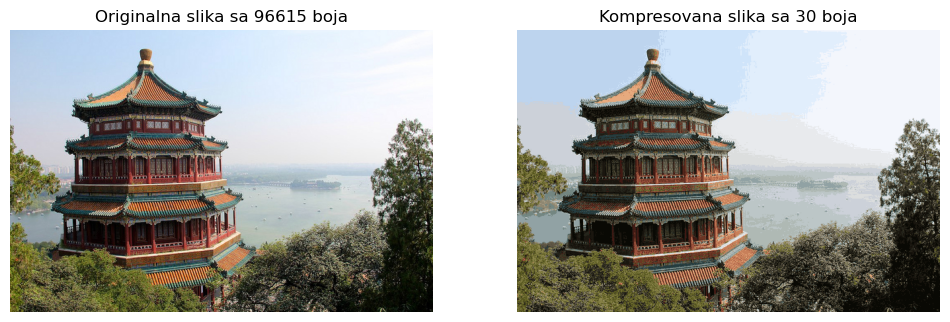

In [46]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('Originalna slika sa 96615 boja')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_compressed)
plt.title('Kompresovana slika sa 30 boja')
plt.axis('off')

plt.show()

## Bisecting K-means

Bisecting K-Means algorithm se zasniva na sledećoj ideji: Prvo podeliti instance u 2 klastera, zatim izabrati jedan od prethodno dobijenih klastera i podeliti ga na 2 klastera. Postupak se ponavlja dok se ne formira $k$ klastera.

Izbor klastera za podelu se može izvršiti na više načina: možemo izabrati najveći klaster, klaster sa najvećom *SSE* ili kriterijum koji se zasniva na kombinaciji veličine klastera i *SSE*. Ova odluka utiče na rezultujuće klastere.

<img src="assets/bisecting_kmeans.png" width="90%">

Često se rezultujuće centroide Bisecting K-Means algoritma koriste kao inicijalne centroide za klasičan K-Means algoritam. Ovaj korak je potreban pošto osnovna varijanta K-Means algoritma pronalazi klastere koji predstavljaju lokalni minimum u odnosu na *SSE*, dok kod Bisecting K-Means osnovni K-Means koristimo samo lokalno, za podelu izabranog klastera. Dakle, finalni skup klastera nije klasterovanje koje predstavlja lokalni minimum u odnosu na *SSE* (na početku sveske smo definisali klasterovanje kao minimizacioni problem *SSE*).

In [47]:
from sklearn. cluster import BisectingKMeans

In [48]:
b_kmeans = BisectingKMeans(n_clusters=3,bisecting_strategy='largest_cluster')

In [49]:
b_kmeans.fit(X)

,n_clusters,3
,init,'random'
,n_init,1
,random_state,None
,max_iter,300
,verbose,0
,tol,0.0001
,copy_x,True
,algorithm,'lloyd'
,bisecting_strategy,'largest_cluster'


In [50]:
centroids = pd.DataFrame(b_kmeans.cluster_centers_, columns=feature_names)
centroids

,height,weight
0,0.615385,0.383987
1,0.903846,0.869281
2,0.292308,0.104575


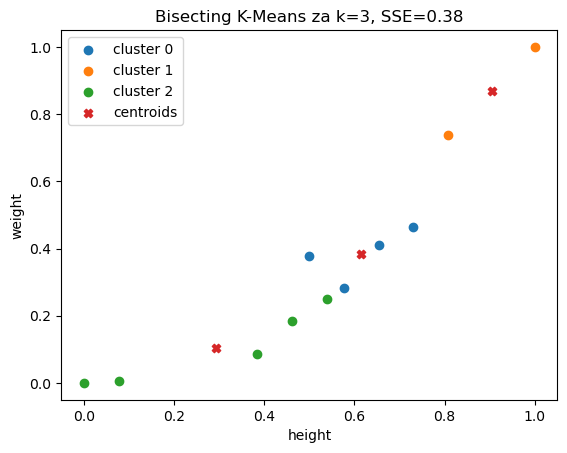

In [51]:
for cluster_label in set(b_kmeans.labels_):
    elems = X[b_kmeans.labels_ == cluster_label]
    plt.scatter(elems['height'], elems['weight'], label='cluster ' + str(cluster_label))

plt.scatter(centroids['height'], centroids['weight'], marker='X', label='centroids') 
    
plt.xlabel('height')
plt.ylabel('weight')
plt.title('Bisecting K-Means za k=3, SSE={}'.format(round(b_kmeans.inertia_, 2)))
plt.legend()
plt.show()   

## Fuzzy C-Means

Svi algoritmi sa kojima smo se do sada upoznali su **hard clustering**, tj. jedna instanca pripada najviše jednom klasteru. Nasuprot tome, postoje i **soft clustering** algoritmi koji dozvoljavaju da instance pripadaju istovremeno većem broju klastera sa različitim stepenom pripadnosti (membership degree/value).

<img src="assets/hard_soft_clustering.png" width="50%">

Fuzzy C-Means (FCM) je jedan predstavnik soft clustering algoritama. C-Means u nazivu označava $c$ centroida (identično kao kod K-Means).

Kod Fuzzy C-Means metoda, imamo **dva parametra** : $\mu_{ij}$ i $c_i$ i **hiper-parametare** : <code>c</code> i <code>m</code>.

* $\mu_{ij}$ &ensp;&ndash;&ensp; membership degree/value (stepen pripadnosti) - verovatnoća da $j$-ta instanca pripada $i$-tom klasteru.
Ograničenja:
    
    * $\mu_{ij} \in [0, 1]$ &ensp; $\forall i, j$
    
    * $\sum_{i=1}^{c} \mu_{ij} = 1$ &ensp; $\forall j$
 

* $c_i$ &ensp;&ndash;&ensp; centroide za svaki klaster

* <code>c</code> &ensp;&ndash;&ensp; broj klastera

* <code>m</code> $\geq 1$ &ensp;&ndash;&ensp; fuzzifier parametar, kontroliše koliko će granice klastera biti fuzzy (preklapajuće)


### Minimizacioni problem

You can understand the objective function as a weighted sum of the distance between the data points ($X_j$) and the cluster centers ($C_i$). The “distance” term is the L2 norm in the equation above, and in the example

$ J = \sum_{i=1}^{C}\sum_{j=1}^{N}\mu_{ij}^md(x_j, c_i)$, gde je

$C$ - broj klastera <br>
$N$ - broj instanci <br>
$x_j$ - $j$-ta instanca <br>
$c_i$ - centroida za $i$-ti klaster <br>
$d$ - rastojanje, npr. L2 norma (euklidsko rastojanje)

Formula predstavlja _težinsku sumu_ rastojanja između tačaka iz podataka ($x_j$) i centroide klastera ($c_i$).

Suma je "otežana" sa $\mu{ij}^m$. Pošto minimizujemo $J$, za bliže instance centroidi imamo veće vrednosti $\mu_{ij}$. Zato nam je bitan i hiper-parametar $m$.  Ako za vrednost $m$ uzmemo jako velike vrednosti, rastojanje više nema veliki uticaj (jer je $\mu_{ij}^m$ blisko 0) i sve centroide će se nalaziti oko centra svih podataka - time se onda sve tačke nalaze u velikom broju klastera. 

Dakle, intuitivno, za veliko $m$ - instance pripadaju većem broju klastera, za malo $m$ - instance pripadaju malom broju klastera.

#### Pronalazak parametara koji minimizuju J 

[Litetatura sa izvođenjem formula.](https://www.sciencedirect.com/science/article/abs/pii/0098300484900207)

Ostalo je još pitanje pronalaska parametara $c_i$ i $\mu_{ij}$ koji minimizuju $J$:

* $c_i = \frac{\sum_{j=1}^N \mu_{ij}^mxj}{\sum_{j=1}^N \mu_{ij}^m}$
* $\mu_{ij} = \frac{1}{\sum_{k=1}^{C}(\frac{||x_j-c_i||}{||x_j-c_k||})^{\frac{2}{m-1}}}$

Dakle, Fuzzy C-Means algoritam iterativno ažurira $c_i$ i $\mu_{ij}$ sve dok promene centroida u dve uzastopne iteracije nije manja od unapred određene granice.

U narednom primeru ćemo prikazati korišćenje *FCM* algoritma. Nakon podešavanja parametara <code>c</code> i <code>m</code>, određujemo klastere.

In [52]:
#Link ka Python dokumentaciji: https://pypi.org/project/fuzzy-c-means/
#!pip install scikit-fuzzy
#!pip install fuzzy-c-means

In [53]:
from fcmeans import FCM

In [54]:
fcm = FCM(n_clusters=3, m=3)     #m - mekoca granice izmedju klastera

In [55]:
fcm.fit(X.to_numpy())

In [56]:
centroids = pd.DataFrame(fcm.centers, columns=feature_names)
centroids

,height,weight
0,0.555590,0.300472
1,0.065388,0.011660
2,0.914342,0.876991


FCM algoritam možemo koristiti i za hard clustering, kada svaku instancu dodelimo jednom klasteru (onom za koji je stepen pripadnosti najveći).

In [57]:
# hard clustering - dodeljivanje tacno jednom klasteru
fcm_labels = fcm.predict(X.to_numpy())                      

Na osnovu vizuelizacije ispod, vidimo da smo dobili slične centroide kao sa K-Means ili Bisecting K-Means.

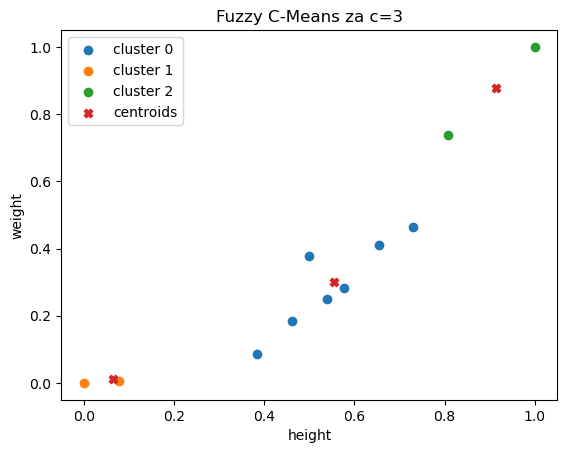

In [58]:
for cluster_label in set(fcm_labels):
    elems = X[fcm_labels == cluster_label]
    plt.scatter(elems['height'], elems['weight'], label='cluster ' + str(cluster_label))

plt.scatter(centroids['height'], centroids['weight'], marker='X', label='centroids') 
    
plt.xlabel('height')
plt.ylabel('weight')
plt.title('Fuzzy C-Means za c=3')
plt.legend()
plt.show()  

Da bismo dobili informacije o stepenu pripadnosti različitim klasterima, koristićemo <code>soft_predict</code>.

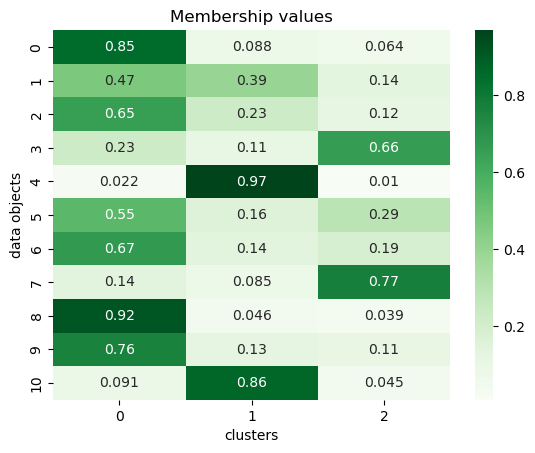

In [59]:
import seaborn as sns
sns.heatmap(fcm.soft_predict(X.to_numpy()), cmap='Greens', annot=True)
plt.title("Membership values")
plt.xlabel('clusters')
plt.ylabel('data objects')
plt.show()

 Pitanje? Da li gore pokazanim heuristikama za hard clustering možemo da biramo broj klastera za Fuzzy C-Means?
 [Dodatna literatura](https://ieeexplore.ieee.org/document/6412415).